<a href="https://colab.research.google.com/github/ghadirchhade/Master-Thesis/blob/main/E010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [3]:
!pip install -q torch torchvision

In [5]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# facebook/sam3 is gated on the Hub -> you must accept the license at
# https://huggingface.co/facebook/sam3 with the account whose token you use below.
!pip install -q -U transformers accelerate huggingface_hub supervision

from huggingface_hub import login
login()  # paste your HF token (needs access to facebook/sam3)

print("Transformers SAM3 dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 5.8 MB/s eta 0:00:00
Transformers SAM3 dependencies installed.


In [7]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import io
import base64
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
from sklearn.cluster import DBSCAN
from torchvision import transforms as T
import supervision as sv
from supervision.metrics import MeanAveragePrecision

from transformers import Sam3Processor, Sam3Model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [9]:
# ============================================================
# CELL 2 — Paths
# ============================================================
IMAGE_PATH_target = "/content/drive/MyDrive/master thesis/AGS_Multi_Rumex/images/20230426_Wallenwil/DJI_20230426110736_0035.JPG"
LABEL_PATH_target = "/content/drive/MyDrive/master thesis/AGS_Multi_Rumex/annotations_yolo/DJI_20230426110736_0035.txt"

IMAGE_PATH_reference = "/content/drive/MyDrive/master thesis/AGS_Multi_Rumex/images/20230426_Wallenwil/DJI_20230426111205_0193.JPG"
LABEL_PATH_reference = "/content/drive/MyDrive/master thesis/AGS_Multi_Rumex/annotations_yolo/DJI_20230426111205_0193.txt"

RUMEX_CLASS_ID = 0

In [10]:
# ============================================================
# CELL 3 — YOLO box loader + load TARGET image & GT
# ============================================================
def load_yolo_boxes(label_path, img_width, img_height, class_id=0):
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            if cls != class_id:
                continue
            xc, yc, bw, bh = map(float, parts[1:5])
            xc, yc, bw, bh = xc * img_width, yc * img_height, bw * img_width, bh * img_height
            boxes.append([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2])
    return np.array(boxes, dtype=np.float32)

target_image = Image.open(IMAGE_PATH_target).convert("RGB")
target_img_w, target_img_h = target_image.size
print(f"Target image size (W, H): {target_image.size}")

gt_boxes_target = load_yolo_boxes(LABEL_PATH_target, target_img_w, target_img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes_target)} GT box(es) on TARGET image with class id={RUMEX_CLASS_ID}.")

Target image size (W, H): (8192, 5460)
Loaded 57 GT box(es) on TARGET image with class id=0.


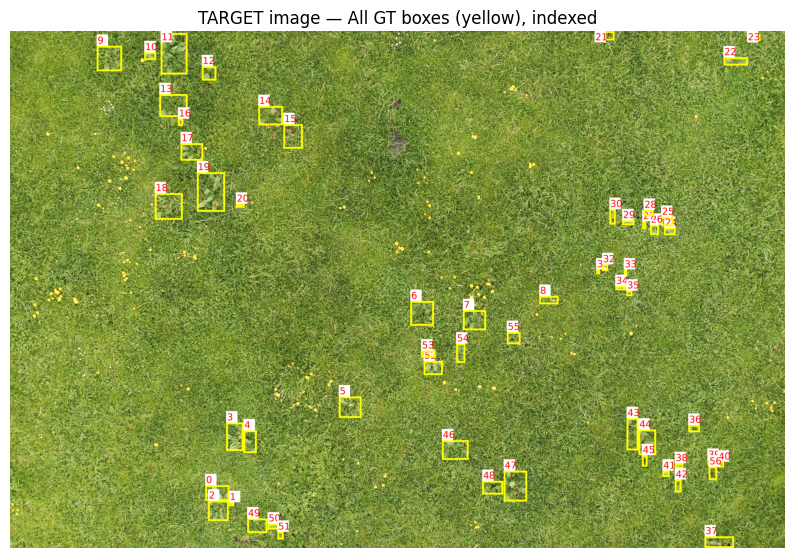

In [11]:
# ============================================================
# CELL 4 — Visualize TARGET image GT boxes (indexed)
# ============================================================
font_path = fm.findfont("DejaVu Sans")
font = ImageFont.truetype(font_path, 100)

def draw_indexed_boxes(base_image, boxes, color=(255, 255, 0)):
    preview = base_image.copy()
    draw = ImageDraw.Draw(preview)
    for i, (x0, y0, x1, y1) in enumerate(boxes):
        draw.rectangle([x0, y0, x1, y1], outline=color, width=20)
        text_x, text_y = int(x0), max(0, int(y0) - 120)
        draw.rectangle([text_x, text_y, text_x + 120, text_y + 120], fill=(255, 255, 255))
        draw.text((text_x + 10, text_y + 5), str(i), fill=(255, 0, 0), font=font)
    return preview

target_gt_preview = draw_indexed_boxes(target_image, gt_boxes_target)
plt.figure(figsize=(10, 8))
plt.imshow(target_gt_preview)
plt.title("TARGET image — All GT boxes (yellow), indexed")
plt.axis("off")
plt.show()

In [12]:
# ============================================================
# CELL 5 — Load REFERENCE image + GT boxes
# ============================================================
reference_image = Image.open(IMAGE_PATH_reference).convert("RGB")
ref_img_w, ref_img_h = reference_image.size
print(f"Reference image size (W, H): {reference_image.size}")

gt_boxes_reference = load_yolo_boxes(LABEL_PATH_reference, ref_img_w, ref_img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes_reference)} GT box(es) on REFERENCE image with class id={RUMEX_CLASS_ID}.")

Reference image size (W, H): (8192, 5460)
Loaded 48 GT box(es) on REFERENCE image with class id=0.


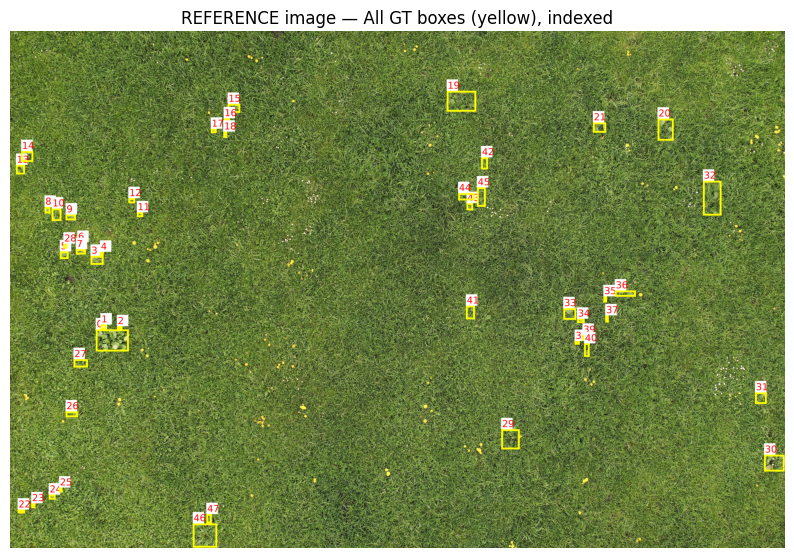

In [13]:
# ============================================================
# CELL 6 — Visualize REFERENCE image GT boxes (indexed)
# ============================================================
ref_gt_preview = draw_indexed_boxes(reference_image, gt_boxes_reference)
plt.figure(figsize=(10, 8))
plt.imshow(ref_gt_preview)
plt.title("REFERENCE image — All GT boxes (yellow), indexed")
plt.axis("off")
plt.show()

Using exemplar box (idx 19): [4616.7509765625, 631.458984375, 4928.5341796875, 852.469970703125]


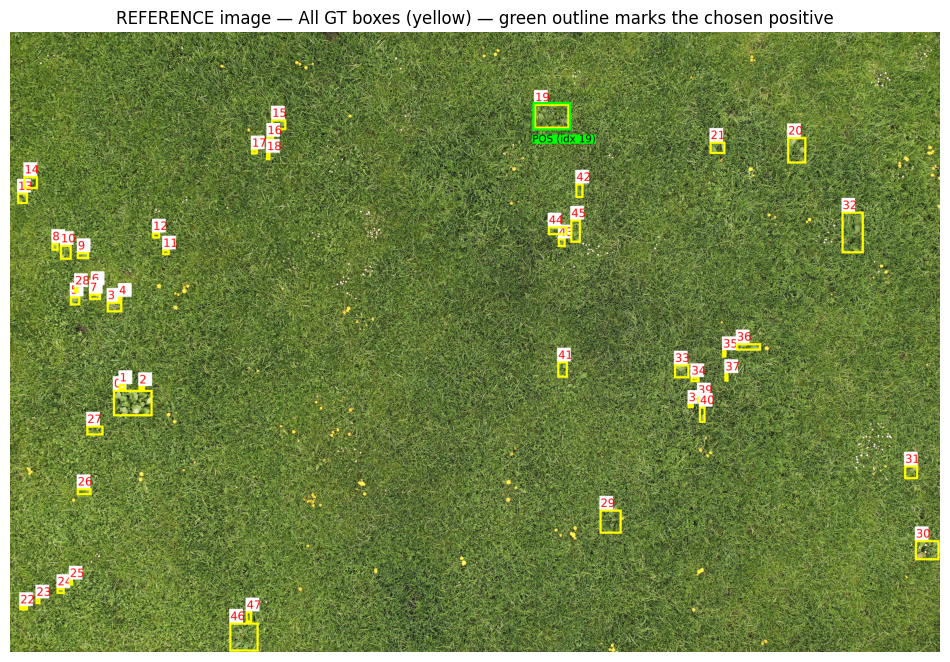

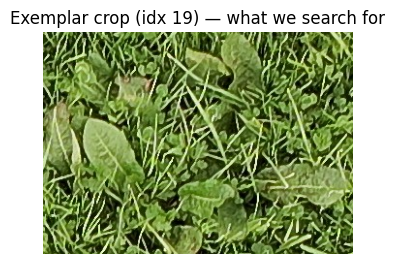

In [15]:
# ============================================================
# CELL 7 — Choose ONE positive exemplar by index (from REFERENCE image GT),
# crop it, and highlight against all reference GT boxes
# ============================================================
# NEW: pick several exemplars that look representative of different plant
# sizes/appearances in the reference image. More exemplars = more reference
# patches = more robust matching in cell 11.

positive_indices = [19, 44, 2, 34, 4]  # <-- edit: pick a handful of clear, varied GT indices

exemplar_preview = draw_indexed_boxes(reference_image, gt_boxes_reference)
draw = ImageDraw.Draw(exemplar_preview)
HIGHLIGHT_PAD = 15
label_font = ImageFont.truetype(font_path, 90)

exemplar_crops = []
for positive_index in positive_indices:
    ex_x0, ex_y0, ex_x1, ex_y1 = gt_boxes_reference[positive_index]
    draw.rectangle(
        [ex_x0 - HIGHLIGHT_PAD, ex_y0 - HIGHLIGHT_PAD, ex_x1 + HIGHLIGHT_PAD, ex_y1 + HIGHLIGHT_PAD],
        outline=(0, 255, 0), width=20,
    )
    label_text = f"POS (idx {positive_index})"
    label_x, label_y = int(ex_x0 - HIGHLIGHT_PAD), int(ex_y1 + HIGHLIGHT_PAD + 20)
    text_bbox = draw.textbbox((label_x, label_y), label_text, font=label_font)
    draw.rectangle(text_bbox, fill=(0, 255, 0))
    draw.text((label_x, label_y), label_text, fill=(0, 0, 0), font=label_font)

    PAD = 4
    crop = reference_image.crop((
        max(0, ex_x0 - PAD), max(0, ex_y0 - PAD),
        min(reference_image.width, ex_x1 + PAD), min(reference_image.height, ex_y1 + PAD),
    ))
    exemplar_crops.append(crop)

plt.figure(figsize=(12, 10))
plt.imshow(exemplar_preview)
plt.axis("off")
plt.title("REFERENCE image — All GT boxes (yellow) — green outlines mark the chosen positives")
plt.show()

fig, axes = plt.subplots(1, len(exemplar_crops), figsize=(4 * len(exemplar_crops), 4))
if len(exemplar_crops) == 1:
    axes = [axes]
for ax, crop, idx in zip(axes, exemplar_crops, positive_indices):
    ax.imshow(crop)
    ax.set_title(f"idx {idx}")
    ax.axis("off")
plt.show()

In [16]:
# ============================================================
# CELL 8 — DINOv2 model load
# ============================================================
# dinov2_vitb14 = good balance of accuracy and speed. Swap for 'dinov2_vits14'
# (faster, less accurate) or 'dinov2_vitl14' (slower, more accurate).
dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
dino_model.eval().to(device)

PATCH_SIZE = 14  # DINOv2's patch size - don't change unless you change the model above

dino_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("DINOv2 loaded.")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:03<00:00, 98.0MB/s]


DINOv2 loaded.


In [17]:
# ============================================================
# CELL 9 — Patch feature extraction function
# ============================================================
@torch.no_grad()
def extract_patch_features(image_pil, max_size=896):
    '''
    image_pil: a PIL image (RGB)
    max_size: the longest side is resized down to at most this many pixels.
    Returns: (feats [N, C] tensor, coords [N, 2] numpy array of (x, y) in ORIGINAL pixels)
    '''
    orig_w, orig_h = image_pil.size
    scale = min(1.0, max_size / max(orig_w, orig_h))
    new_w, new_h = int(orig_w * scale), int(orig_h * scale)
    new_w = max(PATCH_SIZE, (new_w // PATCH_SIZE) * PATCH_SIZE)
    new_h = max(PATCH_SIZE, (new_h // PATCH_SIZE) * PATCH_SIZE)

    resized = image_pil.resize((new_w, new_h))
    tensor = dino_transform(resized).unsqueeze(0).to(device)
    feat_map = dino_model.get_intermediate_layers(tensor, n=1, reshape=True)[0]
    feat_map = feat_map.squeeze(0)  # [C, Hp, Wp]
    C, Hp, Wp = feat_map.shape

    feats = feat_map.permute(1, 2, 0).reshape(-1, C)  # [Hp*Wp, C]
    feats = F.normalize(feats, dim=-1)

    coords = np.zeros((Hp * Wp, 2), dtype=np.float32)
    idx = 0
    for yy in range(Hp):
        for xx in range(Wp):
            px = (xx + 0.5) * (orig_w / Wp)
            py = (yy + 0.5) * (orig_h / Hp)
            coords[idx] = [px, py]
            idx += 1

    return feats.cpu(), coords

print("Feature extraction function ready.")

Feature extraction function ready.


In [ ]:
# ============================================================
# CELL 9b — Tiled feature extraction (REFINEMENT #2 — the main fix)
# ============================================================
# OLD: the whole target image (likely 4000-5280px) was downscaled to a max
# side of 700-1050px before feature extraction. A ~150px Rumex plant would
# shrink to ~20-30px -> only 1-3 DINOv2 patches (patch size 14px) -> the
# object's embedding gets swamped by surrounding grass. This is very likely
# why cell 12/16 produced ZERO candidates.
#
# NEW: slide a window (tile_size) across the image with overlap, run
# extract_patch_features on each tile near-native resolution (no extra
# downscale needed since the tile is already <= max_size), then map local
# patch coordinates back to global image coordinates. This preserves object
# detail everywhere in the image, not just near the center.

@torch.no_grad()
def extract_patch_features_tiled(image_pil, tile_size=896, overlap=128):
    orig_w, orig_h = image_pil.size
    stride = tile_size - overlap
    all_feats, all_coords = [], []

    tops = list(range(0, max(orig_h - tile_size, 0) + 1, stride)) or [0]
    lefts = list(range(0, max(orig_w - tile_size, 0) + 1, stride)) or [0]
    if tops[-1] + tile_size < orig_h:
        tops.append(orig_h - tile_size)
    if lefts[-1] + tile_size < orig_w:
        lefts.append(orig_w - tile_size)

    for top in tops:
        for left in lefts:
            right = min(left + tile_size, orig_w)
            bottom = min(top + tile_size, orig_h)
            tile = image_pil.crop((left, top, right, bottom))
            feats, coords = extract_patch_features(tile, max_size=tile_size)
            coords = coords + np.array([left, top], dtype=np.float32)
            all_feats.append(feats)
            all_coords.append(coords)

    return torch.cat(all_feats, dim=0), np.concatenate(all_coords, axis=0)

print("Tiled feature extraction function ready.")

In [18]:
# ============================================================
# CELL 10 — Extract features for exemplars (with rotation augmentation)
# and tiled TARGET features (REFINEMENT #3)
# ============================================================
# OLD: single exemplar crop -> a handful of patches -> fragile matching.
# NEW: for each exemplar, also add 90/180/270 degree rotations. Aerial plants
# have no canonical "up" direction, so this cheaply multiplies the number of
# reference patches without needing new labeled data.

ref_feats_list, ref_coords_list = [], []
for crop in exemplar_crops:
    for angle in [0, 90, 180, 270]:
        rotated = crop.rotate(angle, expand=True)
        feats, coords = extract_patch_features(rotated)  # small crop, no tiling needed
        ref_feats_list.append(feats)
        ref_coords_list.append(coords)

ref_feats = torch.cat(ref_feats_list, dim=0)
print("Total exemplar patches (all exemplars x rotations):", ref_feats.shape)

# Tiled, near-native-resolution features for the TARGET image.
tgt_feats, tgt_coords = extract_patch_features_tiled(target_image, tile_size=896, overlap=128)
print("Total target patches (tiled):", tgt_feats.shape)

Exemplar patches: torch.Size([352, 768])
Total target patches across all scales: torch.Size([6213, 768])


In [ ]:
# ============================================================
# CELL 10b — DIAGNOSTIC: inspect the similarity score distribution
# (REFINEMENT #4 — do this BEFORE picking a threshold)
# ============================================================
# This is the cheapest possible check: for every target patch, what is its
# best similarity to ANY exemplar patch? If even the top 0.5% of target
# patches sit below your intended threshold, no fixed threshold like 0.55
# will ever produce candidates — the threshold itself is the bug, not the
# clustering or SAM3 stage downstream.

with torch.no_grad():
    sim_full = ref_feats @ tgt_feats.T          # [num_ref_patches, num_tgt_patches]
    best_per_target = sim_full.max(dim=0).values  # [num_tgt_patches]

best_per_target_np = best_per_target.numpy()
print("Max similarity per target patch — percentiles:")
for p in [50, 90, 95, 99, 99.5, 99.9]:
    print(f"  {p:>5}th pct: {np.percentile(best_per_target_np, p):.3f}")
print(f"  max        : {best_per_target_np.max():.3f}")

plt.figure(figsize=(8, 4))
plt.hist(best_per_target_np, bins=100)
plt.title("Distribution of best-match similarity per target patch")
plt.xlabel("cosine similarity")
plt.ylabel("count")
plt.show()

# Read this before continuing: if the 99th percentile is well below 0.55,
# lower SIMILARITY_THRESHOLD in the next cell accordingly (or use the
# adaptive/percentile-based threshold option provided there).

In [19]:
# ============================================================
# CELL 11 — Bidirectional matching with adaptive threshold option
# (REFINEMENT #5)
# ============================================================
# OLD: a single fixed SIMILARITY_THRESHOLD = 0.55, tuned by guesswork.
# NEW: option to set the threshold adaptively from the score distribution
# you just inspected in cell 10b (e.g. "top 1% of target patch scores"),
# so it adapts to this specific image/exemplar pair instead of being a
# magic constant that may not transfer across images.

USE_ADAPTIVE_THRESHOLD = True
ADAPTIVE_PERCENTILE = 99.0     # only used if USE_ADAPTIVE_THRESHOLD = True
FIXED_SIMILARITY_THRESHOLD = 0.55  # only used if USE_ADAPTIVE_THRESHOLD = False

if USE_ADAPTIVE_THRESHOLD:
    SIMILARITY_THRESHOLD = float(np.percentile(best_per_target_np, ADAPTIVE_PERCENTILE))
    print(f"Adaptive threshold (top {100 - ADAPTIVE_PERCENTILE:.1f}% of scores): {SIMILARITY_THRESHOLD:.3f}")
else:
    SIMILARITY_THRESHOLD = FIXED_SIMILARITY_THRESHOLD
    print(f"Fixed threshold: {SIMILARITY_THRESHOLD:.3f}")

def bidirectional_match(ref_feats, tgt_feats, threshold):
    sim = ref_feats @ tgt_feats.T
    forward_best = sim.argmax(dim=1)
    reverse_best = sim.argmax(dim=0)

    kept_target_indices = []
    kept_scores = []
    for i in range(ref_feats.shape[0]):
        j = forward_best[i].item()
        if reverse_best[j].item() == i:
            score = sim[i, j].item()
            if score > threshold:
                kept_target_indices.append(j)
                kept_scores.append(score)
    return kept_target_indices, kept_scores

matched_idx, matched_scores = bidirectional_match(ref_feats, tgt_feats, SIMILARITY_THRESHOLD)
matched_points = tgt_coords[matched_idx]

print(f"Found {len(matched_points)} confirmed matching points in the TARGET image.")

# If this is still 0, drop USE_ADAPTIVE_THRESHOLD's percentile lower (e.g. 95),
# or revisit cell 7's exemplar choices — some may be poor visual matches to
# what's actually present in the target image.

Found 67 confirmed matching points in the TARGET image.


Proposed 0 candidate object box(es) (x1,y1,x2,y2):


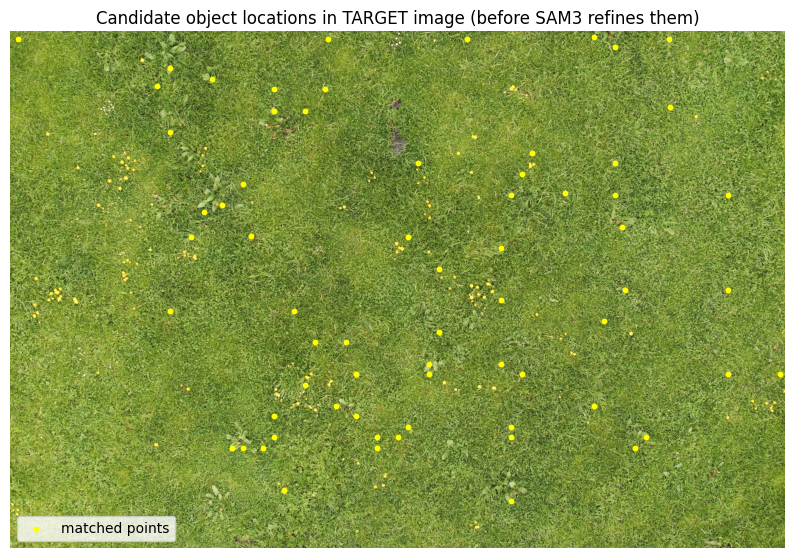

In [20]:
# ============================================================
# CELL 12 — Cluster matched points into candidate boxes (DBSCAN) + visualize
# ============================================================
CLUSTER_DISTANCE_PX = 50    # points closer than this are considered part of the same object
MIN_POINTS_PER_CLUSTER = 2  # ignore clusters supported by fewer points than this (likely noise)
BOX_PADDING_PX = 10         # extra margin added around each cluster's box

def points_to_boxes(points, eps=CLUSTER_DISTANCE_PX, min_samples=MIN_POINTS_PER_CLUSTER, pad=BOX_PADDING_PX):
    if len(points) == 0:
        return []
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    labels = clustering.labels_
    boxes = []
    for label in set(labels):
        if label == -1:
            continue
        cluster_pts = points[labels == label]
        x1, y1 = cluster_pts.min(axis=0) - pad
        x2, y2 = cluster_pts.max(axis=0) + pad
        x1 = max(0, x1); y1 = max(0, y1)
        x2 = min(target_image.width, x2); y2 = min(target_image.height, y2)
        boxes.append([float(x1), float(y1), float(x2), float(y2)])
    return boxes

candidate_boxes_xyxy = points_to_boxes(matched_points)
print(f"Proposed {len(candidate_boxes_xyxy)} candidate object box(es) (x1,y1,x2,y2):")
for b in candidate_boxes_xyxy:
    print("  ", [round(v, 1) for v in b])

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(target_image)
ax.scatter(matched_points[:, 0], matched_points[:, 1], c='yellow', s=10, label='matched points')
for b in candidate_boxes_xyxy:
    rect = plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)
ax.set_title("Candidate object locations in TARGET image (before SAM3 refines them)")
ax.legend()
ax.axis("off")
plt.show()

In [21]:
# ============================================================
# CELL 13 — Load HF SAM3 model + processor
# ============================================================
sam3_model = Sam3Model.from_pretrained("facebook/sam3").to(device)
sam3_processor = Sam3Processor.from_pretrained("facebook/sam3")
sam3_model.eval()
print("Hugging Face SAM3 model + processor loaded.")

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Hugging Face SAM3 model + processor loaded.


In [ ]:
# ============================================================
# CELL 14a — OPTIONAL REFINEMENT: SAM3 text/concept prompting as a
# parallel candidate source
# ============================================================
# SAM3 is trained for open-vocabulary / promptable concept segmentation,
# which is closer to what you actually want than hand-rolled DINOv2 patch
# matching. Try a text prompt describing the plant and compare its raw
# proposals against your DINOv2-derived candidate_boxes_xyxy. You can later
# merge both candidate sets before running cell 14b, or just use whichever
# performs better on its own.

TEXT_PROMPT = "broadleaf weed"  # <-- try variations: "dock leaf", "Rumex plant", "weed rosette"

def run_sam3_with_text(image, text_prompt, threshold=0.3):
    inputs = sam3_processor(
        images=image,
        text=text_prompt,
        return_tensors="pt",
    ).to(sam3_model.device)

    with torch.no_grad():
        outputs = sam3_model(**inputs)

    results = sam3_processor.post_process_instance_segmentation(
        outputs, threshold=threshold, mask_threshold=0.4,
        target_sizes=inputs["original_sizes"].tolist(),
    )[0]

    return results["boxes"], results["scores"], results["masks"]

text_boxes, text_scores, text_masks = run_sam3_with_text(target_image, TEXT_PROMPT, threshold=0.3)
print(f"SAM3 text-prompt('{TEXT_PROMPT}') returned {len(text_boxes)} raw proposal(s).")

# Quick visual sanity check of the text-prompt-only proposals
show_image_with_boxes_preview = None  # placeholder, see cell 16's helper for full plotting

In [22]:
# ============================================================
# CELL 14b — Run SAM3 (HF) on the TARGET image using the DINOv2-derived
# candidate boxes as positive box prompts (same as before)
# ============================================================
CONFIDENCE_THRESHOLD = 0.3

def run_sam3_with_boxes(image, boxes_xyxy, threshold=CONFIDENCE_THRESHOLD):
    if len(boxes_xyxy) == 0:
        return [], [], []

    labels = [1] * len(boxes_xyxy)

    inputs = sam3_processor(
        images=image,
        input_boxes=[[[float(c) for c in box] for box in boxes_xyxy]],
        input_boxes_labels=[labels],
        return_tensors="pt",
    ).to(sam3_model.device)

    with torch.no_grad():
        outputs = sam3_model(**inputs)

    results = sam3_processor.post_process_instance_segmentation(
        outputs, threshold=threshold, mask_threshold=0.4,
        target_sizes=inputs["original_sizes"].tolist(),
    )[0]

    return results["boxes"], results["scores"], results["masks"]

raw_boxes, raw_scores, raw_masks = run_sam3_with_boxes(target_image, candidate_boxes_xyxy, threshold=CONFIDENCE_THRESHOLD)
print(f"SAM3 (box-prompted) returned {len(raw_boxes)} raw mask(s) at threshold={CONFIDENCE_THRESHOLD}.")

SAM3 returned 0 raw mask(s) at threshold=0.3.


In [23]:
# ============================================================
# CELL 15 — Merge overlapping duplicate detections (mask IoU based)
# ============================================================
def mask_iou(mask_a, mask_b):
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return intersection / union if union > 0 else 0.0

def merge_overlapping_masks(masks, boxes, scores, iou_threshold=0.3):
    """
    If two masks overlap a lot, they're almost certainly the SAME real object
    detected twice - keep only the higher-confidence one and drop the other.
    """
    scores_list = [float(s.item() if torch.is_tensor(s) else s) for s in scores]
    order = sorted(range(len(scores_list)), key=lambda i: scores_list[i], reverse=True)
    keep, used = [], set()

    masks_np = [np.squeeze(m.cpu().numpy() if torch.is_tensor(m) else np.array(m)) for m in masks]

    for i in order:
        if i in used:
            continue
        keep.append(i)
        for j in order:
            if j == i or j in used:
                continue
            if mask_iou(masks_np[i], masks_np[j]) > iou_threshold:
                used.add(j)

    merged_masks = [masks[i] for i in keep]
    merged_boxes = [boxes[i] for i in keep]
    merged_scores = [scores_list[i] for i in keep]
    return merged_masks, merged_boxes, merged_scores

final_masks, final_boxes_t, final_scores = merge_overlapping_masks(raw_masks, raw_boxes, raw_scores, iou_threshold=0.3)

final_boxes = [
    [float(v) for v in (b.tolist() if torch.is_tensor(b) else b)] for b in final_boxes_t
]

print(f"{len(final_boxes)} final mask(s) after merging overlapping duplicates.")
for i, (box, score) in enumerate(zip(final_boxes, final_scores)):
    print(f"  instance {i}: confidence={score:.3f}, box={[round(v, 1) for v in box]}")

0 final mask(s) after merging overlapping duplicates.


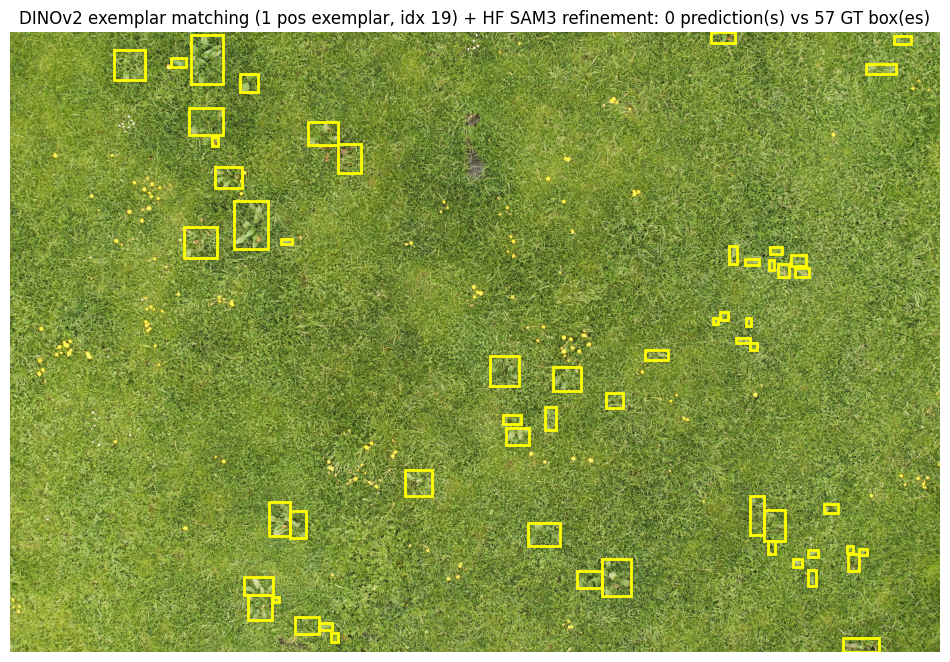

In [24]:
# ============================================================
# CELL 16 — Display final detections (lime) vs TARGET image GT boxes (yellow)
# ============================================================
def show_image_with_boxes(image, boxes_xyxy, masks=None, scores=None, gt_boxes_xyxy=None, title=""):
    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(image)
    ax.set_xlim(0, image.width)
    ax.set_ylim(image.height, 0)

    rng = np.random.default_rng(0)

    if masks is not None:
        for mask in masks:
            mask_np = mask.cpu().numpy() if torch.is_tensor(mask) else np.array(mask)
            mask_np = np.squeeze(mask_np)
            color = rng.uniform(0.2, 1.0, size=3)
            overlay = np.zeros((*mask_np.shape, 4))
            overlay[mask_np > 0.5] = (*color, 0.45)
            ax.imshow(overlay, extent=[0, image.width, image.height, 0])

    if gt_boxes_xyxy is not None:
        for gx1, gy1, gx2, gy2 in gt_boxes_xyxy:
            rect = patches.Rectangle(
                (gx1, gy1), gx2 - gx1, gy2 - gy1,
                linewidth=2, edgecolor="yellow", facecolor="none",
            )
            ax.add_patch(rect)

    for i, box in enumerate(boxes_xyxy):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        if scores is not None:
            ax.text(
                x1, y1 - 5, f"{scores[i]:.2f}",
                color="lime", fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"),
            )

    ax.set_title(title)
    ax.axis("off")
    plt.show()

show_image_with_boxes(
    target_image,
    boxes_xyxy=final_boxes,
    masks=final_masks,
    scores=final_scores,
    gt_boxes_xyxy=gt_boxes_target,
    title=(f"DINOv2 exemplar matching (1 pos exemplar, idx {positive_index}) + HF SAM3 refinement: "
           f"{len(final_boxes)} prediction(s) vs {len(gt_boxes_target)} GT box(es)"),
)

In [25]:
# ============================================================
# CELL 17 — Compute detection metrics (box-based) against TARGET image GT
# ============================================================
pred_boxes_np = np.array(final_boxes, dtype=np.float32) if final_boxes else np.zeros((0, 4), dtype=np.float32)
pred_scores_np = np.array(final_scores, dtype=np.float32) if final_scores else np.zeros((0,), dtype=np.float32)

pred_detections = sv.Detections(
    xyxy=pred_boxes_np,
    confidence=pred_scores_np,
    class_id=np.zeros(len(pred_scores_np), dtype=int),
)
gt_detections = sv.Detections(
    xyxy=gt_boxes_target,
    class_id=np.zeros(len(gt_boxes_target), dtype=int),
)

map_metric = MeanAveragePrecision()
result = map_metric.update([pred_detections], [gt_detections]).compute()
print(f"mAP50: {result.map50:.4f}")

def compute_iou_matrix(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)))
    x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])
    inter_w = np.clip(x2 - x1, 0, None)
    inter_h = np.clip(y2 - y1, 0, None)
    inter_area = inter_w * inter_h
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union_area = area1[:, None] + area2[None, :] - inter_area
    return np.where(union_area > 0, inter_area / union_area, 0.0)

IOU_THRESHOLD = 0.5
iou_matrix = compute_iou_matrix(pred_boxes_np, gt_boxes_target)
num_preds, num_gt = len(pred_boxes_np), len(gt_boxes_target)

matched_gt = set()
true_positives = 0
matched_ious = []
pred_order = np.argsort(-pred_scores_np) if num_preds > 0 else []

for pred_idx in pred_order:
    if num_gt == 0:
        break
    best_gt_idx = np.argmax(iou_matrix[pred_idx])
    best_iou = iou_matrix[pred_idx, best_gt_idx]
    if best_iou >= IOU_THRESHOLD and best_gt_idx not in matched_gt:
        matched_gt.add(best_gt_idx)
        true_positives += 1
        matched_ious.append(best_iou)

false_positives = num_preds - true_positives
false_negatives = num_gt - true_positives
precision = true_positives / num_preds if num_preds > 0 else 0.0
recall = true_positives / num_gt if num_gt > 0 else 0.0
mean_iou_matched = float(np.mean(matched_ious)) if matched_ious else 0.0
mean_iou_all_gt = float(np.sum(matched_ious) / num_gt) if num_gt > 0 else 0.0

print(f"IoU threshold: {IOU_THRESHOLD}")
print(f"Num predictions: {num_preds} | Num GT boxes: {num_gt}")
print(f"True Positives:  {true_positives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Mean IoU (matched pairs only): {mean_iou_matched:.4f}")
print(f"Mean IoU (over all GT boxes):  {mean_iou_all_gt:.4f}")

mAP50: 0.0000
IoU threshold: 0.5
Num predictions: 0 | Num GT boxes: 57
True Positives:  0
False Positives: 0
False Negatives: 57
Precision: 0.0000
Recall:    0.0000
Mean IoU (matched pairs only): 0.0000
Mean IoU (over all GT boxes):  0.0000
